Dataset Shape: (891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
Features Shape: (891, 7)
Target Shape: (891,)
Training Data: (712, 7)
Testing Data: (179, 7)
Model trained successfully!
First 10 Predictions: [0 0 0 1 1 1 1 0 1 1]
Model Accuracy: 79.89%
Confusion Matrix:
[[96  9]
 [27 47]]
Classific

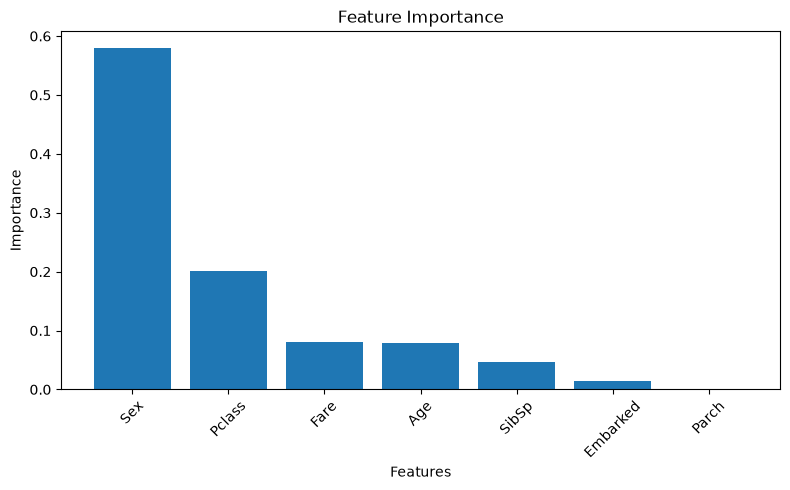

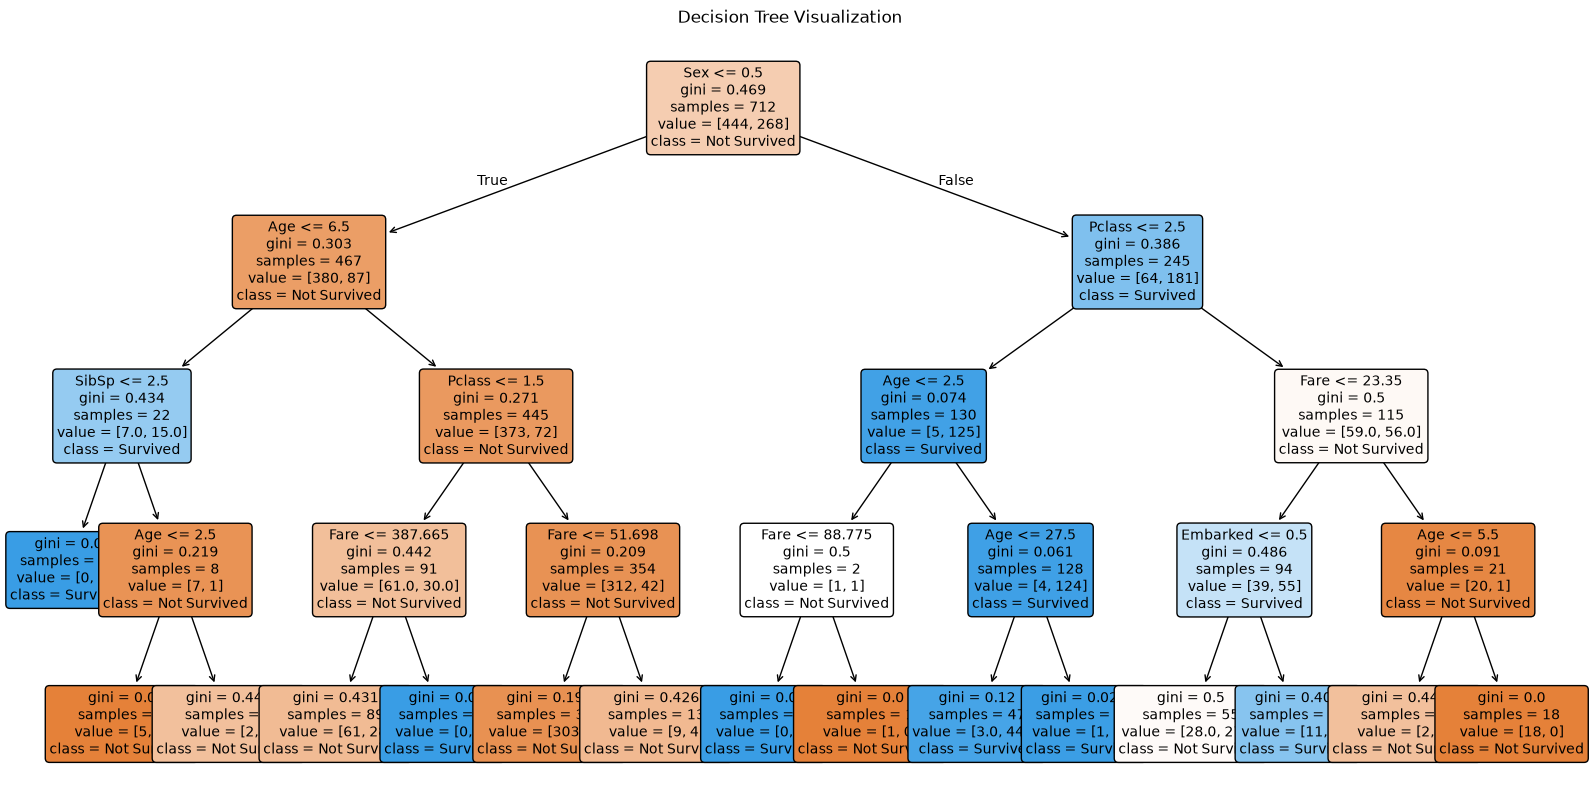

Prediction: Passenger is not likely to survive.


c:\Users\rosmy\CODTECH-ML-INTERNSHIP\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


df = pd.read_csv("train.csv")

df.head()

print("Dataset Shape:", df.shape)

df.info()

df.describe()

df.isnull().sum()
# Fill missing Age values with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with the most frequent value
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Fill missing Fare values (if any)
df["Fare"] = df["Fare"].fillna(df["Fare"].median())

# Drop Cabin because it has too many missing values
df.drop(columns=["Cabin"], inplace=True)
df.isnull().sum()

# Convert Sex column
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

# Convert Embarked column
df["Embarked"] = df["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

df.head()

# Features used for prediction
X = df[[
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]]

# Target variable
y = df["Survived"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

# Predict on the test data
y_pred = model.predict(X_test)

# Display first 10 predictions
print("First 10 Predictions:", y_pred[:10])

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))

plt.bar(importance["Feature"], importance["Importance"])

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Visualization")

plt.show()

sample = [[
    3,      # Pclass
    0,      # Sex (0 = Male)
    22,     # Age
    1,      # SibSp
    0,      # Parch
    7.25,   # Fare
    0       # Embarked (S)
]]

prediction = model.predict(sample)

if prediction[0] == 1:
    print("Prediction: Passenger is likely to survive.")
else:
    print("Prediction: Passenger is not likely to survive.")
    